# 2D CNN — Speech Emotion Recognition

3-channel mel spectrogram (mel + delta-mel + delta2-mel) fed into a 2D depthwise-separable CNN. Best result across all four models at 50% validation accuracy under strict speaker-independent evaluation.

Training was run as a standalone script (`2DCNN.py`). This notebook loads the saved weights and runs diagnostics.

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import glob
import os
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from data_loader import prepare_data

## Config

In [2]:
DATASET_PATH = "Audio_Speech_Actors_01-24"
MAX_LEN      = 300
BATCH_SIZE   = 32
DROPOUT      = 0.3
WEIGHTS_PATH = '2DCNN_best.pth'

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

## Data Loading

Input is a 3-channel mel spectrogram per clip: mel + delta-mel + delta2-mel, shape `(3, 64, 300)`. Deltas computed on the log-mel scale capture temporal dynamics at the spectrogram level rather than just the MFCC coefficients.

CMVN is applied per speaker at load time using training actor statistics only, with a global fallback for unseen val/test speakers.

In [3]:
feature_files = glob.glob(os.path.join(DATASET_PATH, "Actor_*", "*.npz"))

[x_train_torch,
 y_train_torch,
 x_val_torch,
 y_val_torch,
 x_test_torch,
 y_test_torch] = prepare_data(feature_files=feature_files,
                              flatten=False,
                              features=['mel3ch'],
                              max_len=MAX_LEN,
                              apply_cmvn_flag=True)

val_loader = DataLoader(TensorDataset(x_val_torch, y_val_torch), batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {x_train_torch.shape} | Val: {x_val_torch.shape} | Test: {x_test_torch.shape}")
print(f"Train label distribution: {np.bincount(y_train_torch.numpy())}")
print(f"Val label distribution:   {np.bincount(y_val_torch.numpy())}")

Loading data: 100%|██████████| 7200/7200 [00:35<00:00, 204.49it/s]


Train: torch.Size([4800, 3, 64, 300]) | Val: torch.Size([240, 3, 64, 300]) | Test: torch.Size([240, 3, 64, 300])
Train label distribution: [320 640 640 640 640 640 640 640]
Val label distribution:   [16 32 32 32 32 32 32 32]


## Model

Depthwise separable convolutions split a standard Conv2d into two steps: a depthwise conv that applies one filter per input channel independently (captures spatial patterns within each channel cheaply), followed by a pointwise 1x1 conv that mixes across channels (where channel interactions happen). This approximates a full convolution at a fraction of the parameter count.

Channels increase with depth (64 -> 128 -> 256 -> 512) because later layers learn combinations of earlier patterns which occupy a larger representational space.

`AdaptiveAvgPool2d(1)` collapses any spatial size to 1x1 regardless of input dimensions, removing the dependency on fixed input size.

Dropout only on the classifier head, not the conv blocks. Val loss consistently below train loss during training indicated over-regularization in the conv blocks.

In [4]:
class TDcnn(nn.Module):
    def __init__(self, num_classes=8, dropout=DROPOUT):
        super().__init__()

        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Block 1: 64 -> 128
        self.block1 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=7, padding=3, groups=64),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: 128 -> 256
        self.block2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3: 256 -> 512
        self.block3 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=7, padding=3, groups=256),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.init_conv(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = TDcnn(dropout=DROPOUT)
model.load_state_dict(torch.load(WEIGHTS_PATH))
model.eval()
print(f"Loaded weights from {WEIGHTS_PATH}")

Loaded weights from 2DCNN_best.pth


## Validation Results

In [5]:
correct    = 0
total      = 0
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(classification_report(all_labels, all_preds, target_names=list(EMOTION_MAP.values())))
print(f'Val accuracy: {100 * correct / total:.2f}%')

              precision    recall  f1-score   support

     neutral       0.27      0.81      0.41        16
        calm       0.89      0.25      0.39        32
       happy       0.50      0.53      0.52        32
         sad       0.28      0.22      0.25        32
       angry       0.71      0.78      0.75        32
     fearful       0.53      0.59      0.56        32
     disgust       0.81      0.41      0.54        32
   surprised       0.49      0.56      0.52        32

    accuracy                           0.50       240
   macro avg       0.56      0.52      0.49       240
weighted avg       0.58      0.50      0.50       240

Val accuracy: 50.00%


## Confusion Matrix

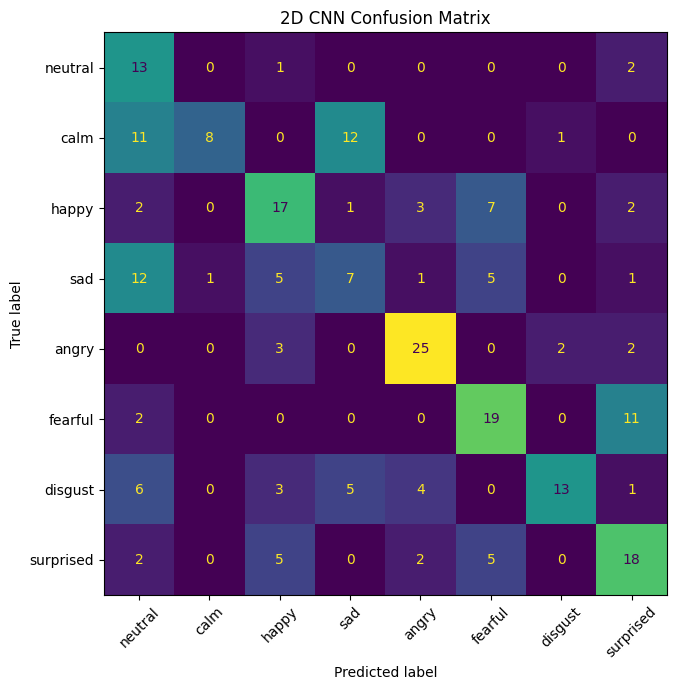

In [6]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(EMOTION_MAP.values()))

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('2D CNN Confusion Matrix')
plt.tight_layout()
plt.show()

## Loss Curve

Saved by the training script to `2DCNN_loss_curve.png`.

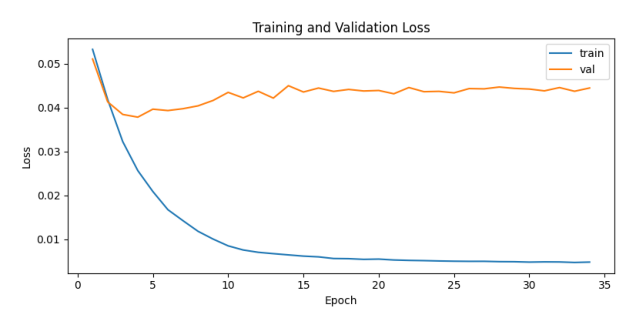

In [7]:
from PIL import Image
img = Image.open('2DCNN_loss_curve.png')
plt.figure(figsize=(8, 4))
plt.imshow(img)
plt.axis('off')
plt.show()